# Imports, Environment and Stuff
## This contains all of my package imports and stuff

imports include

Packages
1. Pandas
2. Matplotlib
3. Scikit-learn
4. XGBoost
5. Shap
6. Seaborn
7. Joblib

Dataset:
IBM HR Statistics on worker attrition

### Packages

In [1110]:
from pickle import FALSE

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import shap
from prometheus_client import Summary
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, PrecisionRecallDisplay
from xgboost import XGBClassifier
import seaborn as sns
import joblib

### Dataset

In [1111]:
df = pd.read_csv("./Dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Feature Engineering

Some Processing on Dataset

In [1112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [1113]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Breakdown of Distance from Home by Job Role and Attrition

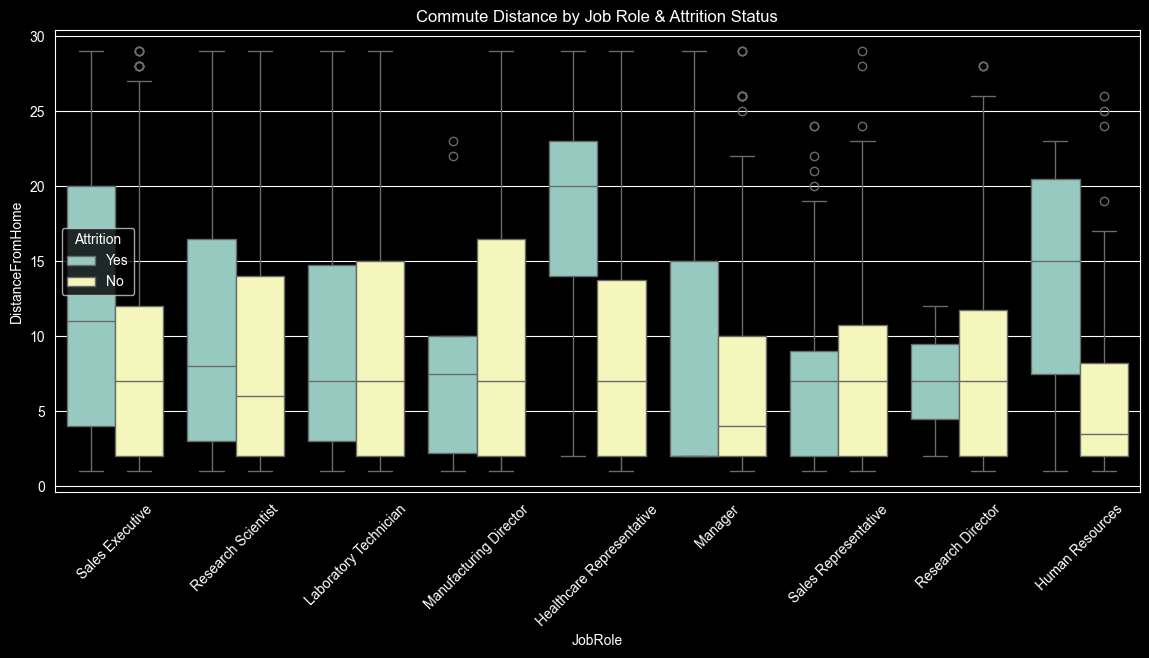

In [1114]:
plt.figure(figsize=(14, 6))
# Create the boxplot
sns.boxplot(data=df, x='JobRole', y='DistanceFromHome', hue='Attrition')

plt.title('Commute Distance by Job Role & Attrition Status')
plt.xticks(rotation=45) # Tilts the job titles so they don't overlap
plt.show()

Compare Average Monthly Income by Education and Attrition

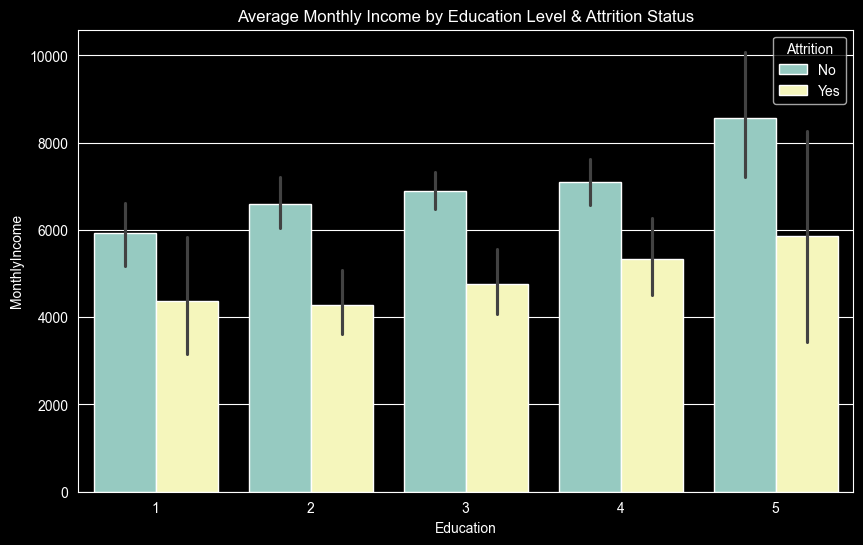

In [1115]:
plt.figure(figsize=(10, 6))
# Create the barplot (Seaborn automatically calculates the average for the y-axis)
sns.barplot(data=df, x='Education', y='MonthlyIncome', hue='Attrition')

plt.title('Average Monthly Income by Education Level & Attrition Status')
plt.show()

Label Encoding Attrition

In [1116]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Dropping Useless Features:
This was done after the model was accessed to determine what was of value

In [1117]:
df = df.drop(['Over18', 'StandardHours', 'EmployeeCount'], axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeNumber            1470 non-null   int64
 9   EnvironmentSatisfaction   1470 non-null   int64
 10  Gender                    1470 non-null   str  
 11  HourlyRate                1470 non-null   int64
 12  JobInvolvement            1470 non-null   int64
 13  JobLevel                  1470 non-null   int64
 14  JobRole                   1470 non-null   str  
 15

## Train/Test Split

Variables

In [1118]:
y = df['Attrition']
X = df.drop('Attrition', axis=1)
scaler = StandardScaler()

X still has columns that are not numerical the following lines of code corrects that AKA Transforming X

In [1119]:
X = pd.get_dummies(X, drop_first=True)

In [1120]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,1,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,2,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,5,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,7,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


Data Split

In [1121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

Standardization AKA feature scaling

we use this method of data scaling to distribute our data about the mean and 1sd to prevent convergence error

In [1122]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models

## Baseline Model
-Linear Regression Model

In [1123]:
bs_model = LogisticRegression(class_weight= 'balanced')
bs_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

### Evaluation

Predictions

In [1124]:
y_predict = bs_model.predict(X_test)

In [1125]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.94      0.76      0.84       245
           1       0.39      0.78      0.52        49

    accuracy                           0.76       294
   macro avg       0.67      0.77      0.68       294
weighted avg       0.85      0.76      0.79       294



Measuring Coefficients to determine Feature Weight

In [1126]:
feature_weights = pd.DataFrame({
    'Feature': X.columns,
    'Importance': bs_model.coef_[0]
}).sort_values(by='Importance', ascending=False)

print(feature_weights)

                              Feature  Importance
26  Department_Research & Development    0.790599
20                     YearsAtCompany    0.751382
44                       OverTime_Yes    0.710234
43               MaritalStatus_Single    0.673179
24   BusinessTravel_Travel_Frequently    0.647083
41       JobRole_Sales Representative    0.593326
27                   Department_Sales    0.485647
35      JobRole_Laboratory Technician    0.481321
22            YearsSinceLastPromotion    0.470569
34            JobRole_Human Resources    0.462034
25       BusinessTravel_Travel_Rarely    0.444672
12                 NumCompaniesWorked    0.442676
40            JobRole_Sales Executive    0.431573
42              MaritalStatus_Married    0.391168
2                    DistanceFromHome    0.329490
14                  PerformanceRating    0.222546
33                        Gender_Male    0.187070
8                            JobLevel    0.171730
11                        MonthlyRate    0.140545


## Hyperparameter Tuning

In [1127]:
# 1. Set up the menu of 'C' values to test (from highly skeptical to highly trusting)
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear'] # A great solver algorithm for smaller datasets
}

In [1128]:
# 2. Build the Grid Search (Keeping the balanced class weights!)
lr_grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    param_grid=lr_param_grid,
    cv=5,
    scoring='recall', # Still optimizing for catching those flight risks
    n_jobs=-1
)

In [1129]:
# 3. Train the 30 different model combinations
lr_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [1130]:
# 4. Get the raw probabilities from the WINNING Logistic Regression model
lr_tuned_probs = lr_grid.predict_proba(X_test)

In [1131]:
# 5. Isolate the "Probability of Leaving" (index 1)
lr_tuned_risk = lr_tuned_probs[:, 1]

In [1132]:
# 6. Apply our custom 30% threshold to ensure a fair, apples-to-apples comparison
final_lr_predictions = (lr_tuned_risk > 0.30).astype(int)

In [1133]:
# 7. Print the winning settings and the ultimate scorecard
print("Best Logistic Regression Parameters:", lr_grid.best_params_)

Best Logistic Regression Parameters: {'C': 0.001, 'solver': 'liblinear'}


Evaluation

In [1134]:
print("\n--- Tuned Logistic Regression Scorecard (30% Threshold) ---")
print(classification_report(y_test, final_lr_predictions))


--- Tuned Logistic Regression Scorecard (30% Threshold) ---
              precision    recall  f1-score   support

           0       0.83      0.02      0.04       245
           1       0.17      0.98      0.28        49

    accuracy                           0.18       294
   macro avg       0.50      0.50      0.16       294
weighted avg       0.72      0.18      0.08       294



## Random Forest Model

In [1135]:
rf_model = RandomForestClassifier(class_weight= 'balanced')
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Evaluation

In [1136]:
y_predict = rf_model.predict(X_test)

In [1137]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92       245
           1       1.00      0.10      0.19        49

    accuracy                           0.85       294
   macro avg       0.92      0.55      0.55       294
weighted avg       0.87      0.85      0.80       294



In [1138]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(rf_importance)

                              Feature  Importance
10                      MonthlyIncome    0.072673
0                                 Age    0.067825
17                  TotalWorkingYears    0.050846
11                        MonthlyRate    0.048457
4                      EmployeeNumber    0.048195
1                           DailyRate    0.045849
6                          HourlyRate    0.045467
20                     YearsAtCompany    0.043917
44                       OverTime_Yes    0.043000
2                    DistanceFromHome    0.037313
23               YearsWithCurrManager    0.036923
13                  PercentSalaryHike    0.031749
21                 YearsInCurrentRole    0.031571
12                 NumCompaniesWorked    0.030128
16                   StockOptionLevel    0.029951
5             EnvironmentSatisfaction    0.028323
9                     JobSatisfaction    0.025599
8                            JobLevel    0.023113
18              TrainingTimesLastYear    0.021924


### Hyperparameter Tuning for RF model

In [1139]:
param_grid = {'max_depth': [5, 10, None], 'min_samples_leaf': [1, 5, 10], 'class_weight': ['balanced', {0: 1, 1: 5}]}

In [1140]:
# 1. Set up the Grid Search
grid_search = GridSearchCV(
    estimator=rf_model, # Your original Random Forest model
    param_grid=param_grid,
    cv=5,               # 5-fold cross-validation
    scoring='recall',   # Optimize for catching Class 1 (Leaves)
    n_jobs=-1           # Uses all your computer's processors to go faster
)

In [1141]:
# 2. Train all 90 models
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', {0: 1, 1: 5}], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is d

In [1142]:
print("Best Parameter for Random Forest:", grid_search.best_params_)

Best Parameter for Random Forest: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 10}


### Setting Threshold and Stuff

In [1143]:
# 1. Get the raw probabilities from our Grid Search model
probabilities = grid_search.predict_proba(X_test)

In [1144]:
# 2. Isolate just the "Probability of Leaving" (index 1)
risk_scores = probabilities[:, 1]

In [1145]:
# 3. Create new predictions using a custom 30% threshold
custom_predictions = (risk_scores > 0.30).astype(int)

Evaluation

In [1146]:
print("\n--- Tuned Random Forest Scorecard (30% Threshold) ---")
print(classification_report(y_test, custom_predictions))


--- Tuned Random Forest Scorecard (30% Threshold) ---
              precision    recall  f1-score   support

           0       0.95      0.38      0.55       245
           1       0.23      0.90      0.36        49

    accuracy                           0.47       294
   macro avg       0.59      0.64      0.45       294
weighted avg       0.83      0.47      0.52       294



Precision Recall Curve

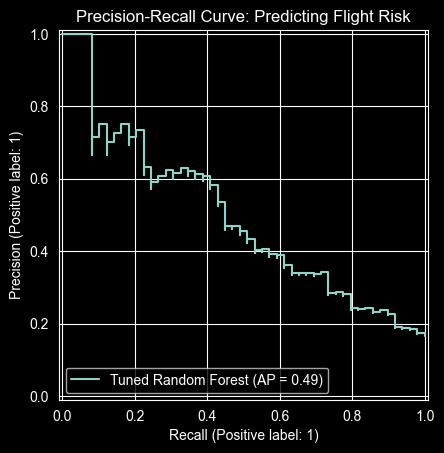

In [1147]:
# Plot the Precision-Recall curve directly from our tuned model
PrecisionRecallDisplay.from_estimator(grid_search, X_test, y_test, name="Tuned Random Forest")
plt.title("Precision-Recall Curve: Predicting Flight Risk")
plt.show()

## XGBoost

In [1148]:
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

### Evaluation

In [1149]:
xgb_predict = xgb_model.predict(X_test)

In [1150]:
print(classification_report(y_test, xgb_predict))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       245
           1       0.64      0.29      0.39        49

    accuracy                           0.85       294
   macro avg       0.75      0.63      0.66       294
weighted avg       0.83      0.85      0.83       294



### HyperParameter Tuning and the Threshold

In [1151]:
# 1. Set up the "Menu" of settings to test
xgb_param_grid = {
    'max_depth': [3, 5, 7],             # Shallow to medium trees
    'learning_rate': [0.01, 0.1, 0.2],  # Slow and steady vs. fast learning
    'n_estimators': [100, 200]          # Number of trees in the relay
}

In [1152]:
# 2. Build the Grid Search (Warning: This will test 18 combinations x 5 folds = 90 models!)
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, scale_pos_weight=5), # Keep the 5x penalty!
    param_grid=xgb_param_grid,
    cv=5,
    scoring='recall', # Still optimizing to catch the flight risks
    n_jobs=-1         # Use all computer cores to speed it up
)

In [1153]:
# 3. Train the models (This might take a few seconds longer than the Random Forest)
xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [1154]:
print("Bet Parameter for XGBoost:", xgb_grid.best_params_)

Bet Parameter for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}


In [1155]:
# 1. Get raw probabilities from the WINNING XGBoost model
xgb_tuned_probs = xgb_grid.predict_proba(X_test)

In [1156]:
# 2. Isolate the "Probability of Leaving" (index 1)
xgb_tuned_risk = xgb_tuned_probs[:, 1]

In [1157]:
# 3. Apply our custom 30% threshold
final_xgb_predictions = (xgb_tuned_risk > 0.30).astype(int)

Evaluation

In [1158]:
# 4. Print the ultimate scorecard
print("\n--- Tuned XGBoost Scorecard (30% Threshold) ---")
print(classification_report(y_test, final_xgb_predictions))


--- Tuned XGBoost Scorecard (30% Threshold) ---
              precision    recall  f1-score   support

           0       0.95      0.33      0.50       245
           1       0.22      0.92      0.35        49

    accuracy                           0.43       294
   macro avg       0.58      0.63      0.42       294
weighted avg       0.83      0.43      0.47       294



# SHAP

In [1159]:
# 1. Create the explainer using our tuned Random Forest model
explainer = shap.TreeExplainer(xgb_grid.best_estimator_)

In [1160]:
# 2. Calculate SHAP values for the test set
shap_values = explainer(X_test)
shap_values.feature_names = list(X.columns)

Why Each Person is Likely to Attrition

In [1161]:
# 1. Visualize the exact reasons for Employee #n's prediction
shap.plots.waterfall(shap_values[7], show=False)

<Axes: >

In [1162]:
# 2. Create custom color patches that match SHAP's exact default colors
red_patch = mpatches.Patch(color='#ff0051', label='Pushes toward ATTRITION (+)')
blue_patch = mpatches.Patch(color='#008bfb', label='Pushes toward NO AT(-)')

In [1163]:
# 3. Add our custom legend to the current plot
plt.legend(handles=[red_patch, blue_patch], loc='lower right', title="Interpretation Key")

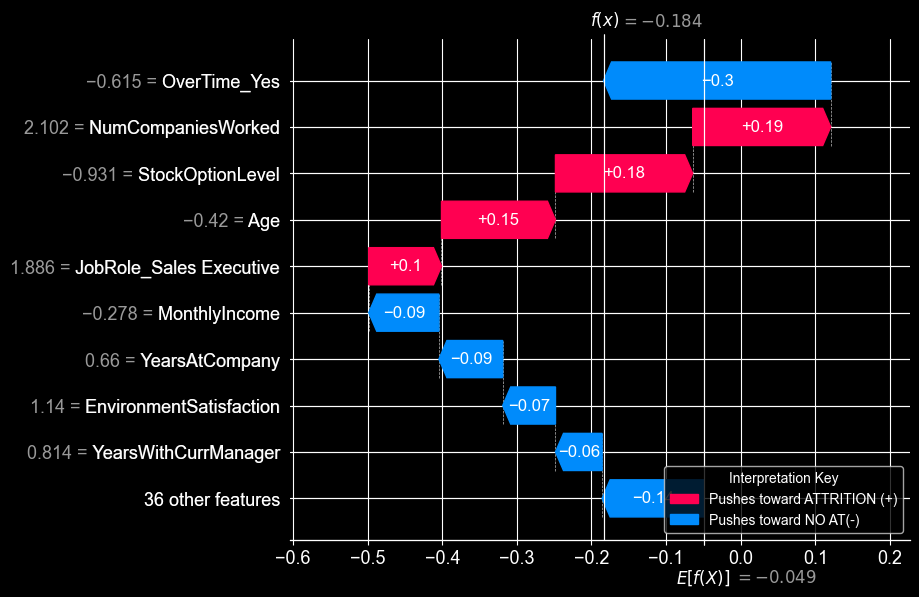

In [1164]:
plt.show()

Global Summary

In [1165]:
# 4. Generate the Global Summary Plot (NO SLICING NEEDED!)
shap.summary_plot(shap_values, X_test, show=False)

In [1166]:
# 2. Create a clean, plain-English explanation box below the X-axis
plt.figtext(
    0.5, -0.05,  # Coordinates (0.5 is perfectly centered, -0.05 is below the chart)
    "<--- More likely to NO ATT  |  More likely to ATT --->",
    ha="center",
    fontsize=12,
    fontweight='bold',
    bbox={"facecolor":"white", "alpha":0.8, "pad":5, "edgecolor":"black"} # Adds a nice border
)

Text(0.5, -0.05, '<--- More likely to NO ATT  |  More likely to ATT --->')

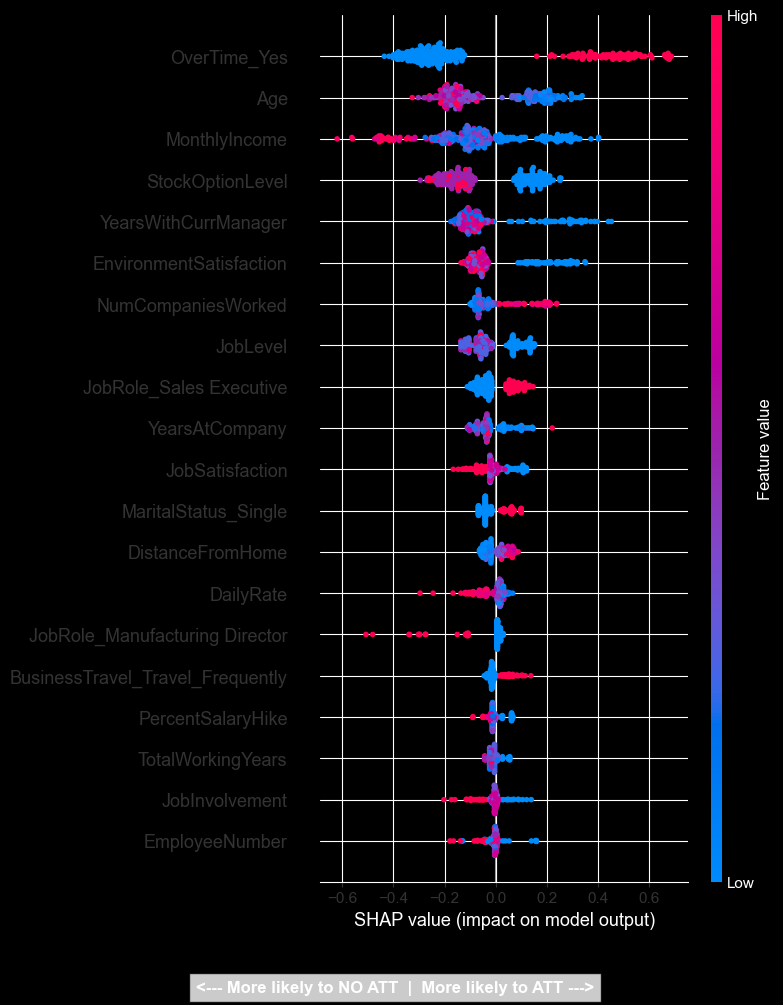

In [1167]:
# 3. Display the final chart
plt.show()

# Deploy

In [1168]:
# Save the winning XGBoost model (with its tuned hyperparameters) to a file
joblib.dump(xgb_grid.best_estimator_, 'hr_flight_risk_model_v1.pkl')

print("Model successfully saved and ready for deployment! 🚀")

Model successfully saved and ready for deployment! 🚀


In [1169]:
# 1. Grab the columns from 'X' (your original dataframe) instead of the scaled 'X_train' array
training_columns = list(X.columns)

# 2. Save that pure list of strings as its own file!
joblib.dump(training_columns, 'hr_model_columns.pkl')

print("Column names successfully saved!")

Column names successfully saved!


In [1170]:
joblib.dump(scaler, 'hr_scaler.pkl')

print("Scaler exported")

Scaler exported


In [1171]:
# 1. Get the median, but convert it to a standard Python dictionary
# This strips away the "StringDtype" that is causing the error
baseline_dict = X.median().to_dict()

# 2. Save the simple dictionary
joblib.dump(baseline_dict, 'hr_baseline_employee.pkl')

print("Baseline dictionary saved successfully! 🚀")

Baseline dictionary saved successfully! 🚀
